In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("train.csv")

In [6]:
#Check Data
print(df.shape)
print(df.info())

(9800, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dt

In [8]:
#Convert dates
# Convert dates with the correct format
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)  # Specifying dayfirst=True for DD/MM/YYYY format
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)    # Specifying dayfirst=True for DD/MM/YYYY format

In [10]:
# Check missing values
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [11]:
#Drop missing (if any)
df = df.dropna()

In [12]:
# Remove duplicates
df = df.drop_duplicates()

In [13]:
#Create new useful columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

### Analysis

In [20]:
#Total Sales
print("Total Sales: $", df['Sales'].sum())

Total Sales: $ 2252607.4127


In [21]:
#Sales by Region
print(df.groupby('Region')['Sales'].sum())

Region
Central    492646.9132
East       660589.3560
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


In [32]:
#Region with highest sales
print(df.groupby('Region')['Sales'].sum().sort_values(ascending=False).head(1))

Region
West    710219.6845
Name: Sales, dtype: float64


In [22]:
# Sales by Category
print(df.groupby('Category')['Sales'].sum())

Category
Furniture          723538.4757
Office Supplies    703212.8240
Technology         825856.1130
Name: Sales, dtype: float64


In [26]:
# Top 5 Products
print(df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head())

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64


### First Visualization

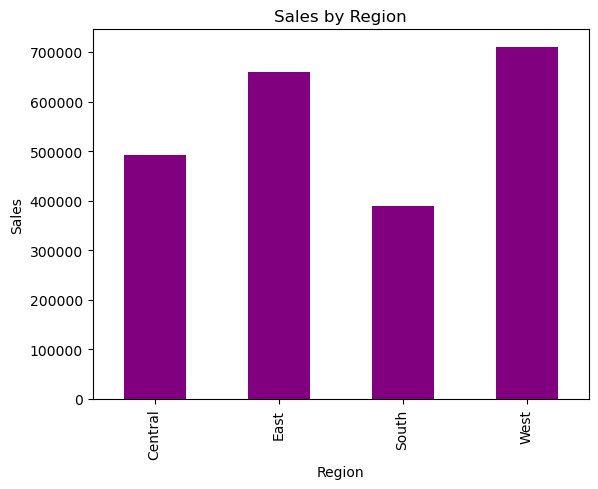

In [44]:
import matplotlib.pyplot as plt

df.groupby('Region')['Sales'].sum().plot(kind='bar', color='purple')
plt.title('Sales by Region')
plt.ylabel('Sales')
plt.show()

### Sales Trend Over Time (Yearly)


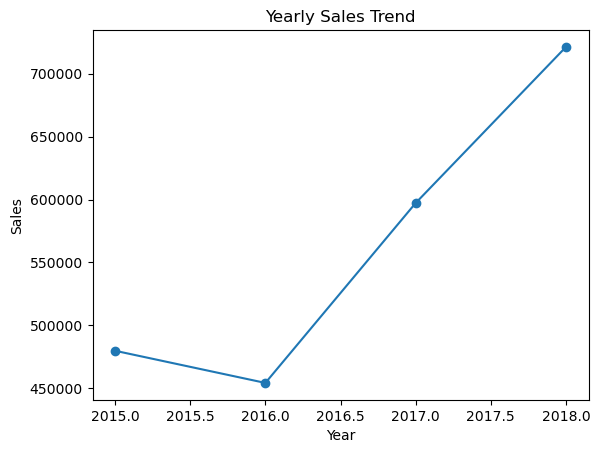

In [34]:
df.groupby('Year')['Sales'].sum().plot(kind= 'line', marker= 'o')
plt.title("Yearly Sales Trend")
plt.ylabel("Sales")
plt.show()

### Sales Trend Over Time (Monthly)

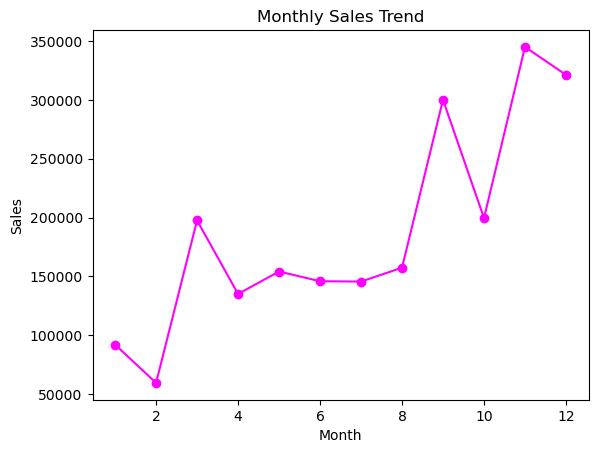

In [45]:
df.groupby('Month')['Sales'].sum().plot(kind= 'line', marker= 'o', color='magenta')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()

### Sales by Category

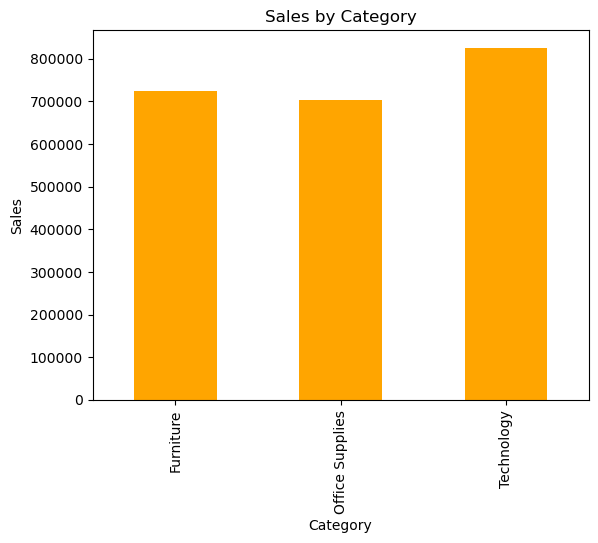

In [48]:
df.groupby('Category')['Sales'].sum().plot(kind= 'bar', color='Orange')
plt.title('Sales by Category')
plt.ylabel('Sales')
plt.show()

### Top 10 Products

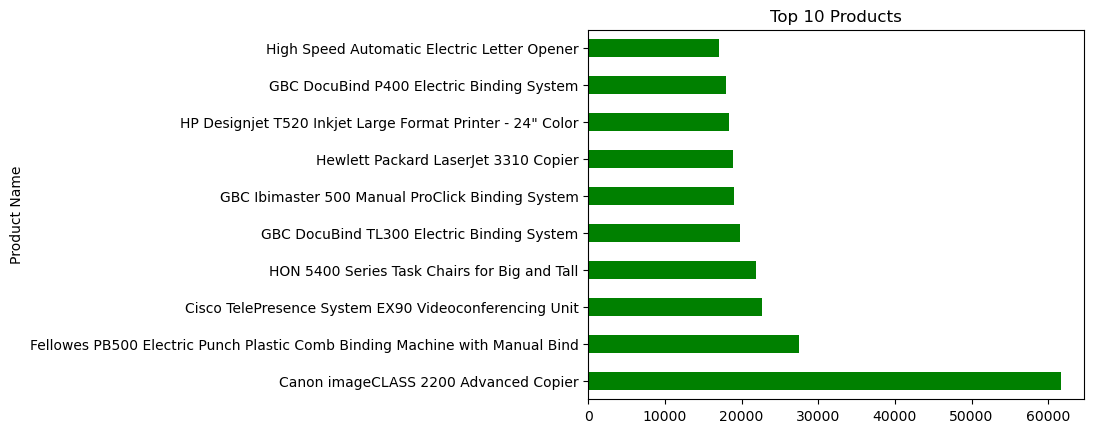

In [47]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='barh', color='green')
plt.title('Top 10 Products')
plt.show()

### Segment Analysis

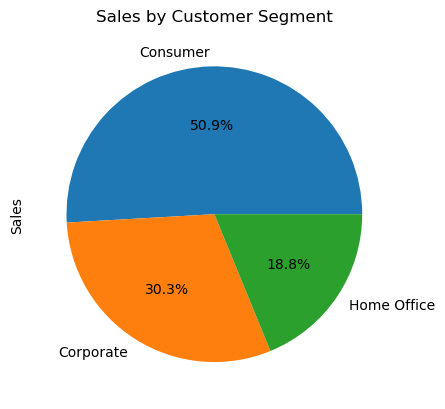

In [49]:
df.groupby('Segment')['Sales'].sum().plot(kind= 'pie', autopct= '%1.1f%%')
plt.title('Sales by Customer Segment')
plt.show()

# INSIGHTS
1. Sales are increasing year by year → business is growing
2. West region contributes highest revenue → focus area
3. Technology category generates most sales
4. Consumer segment contributes highest share

+++++++++++++++++++++++++++++++++++++++++++++++++++++++

1. 📈 Sales show a consistent upward trend year-over-year, indicating business growth
2. 📅 November has the highest sales, suggesting strong seasonal demand (likely due to festivals/discount periods)
3. 🏆 Technology category generates the highest revenue, making it the most valuable segment
4. 👤 Consumer segment contributes the most sales, meaning B2C customers drive the business